<a href="https://colab.research.google.com/github/Amal1703/Car-Detection-using-YOLO/blob/main/Car_Detection_using_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Turn on GPU acceleration

In [ ]:
# In Colab:
# Click Runtime
# Then click Change runtime type
# Under Hardware accelerator, select GPU T4
# Click Save

In [ ]:
# Confirm whether GPU or CPU is being used

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


Import libraries

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from sklearn.model_selection import train_test_split
import pandas as pd
import requests
import zipfile
import io
import os
import sys
import glob
from pathlib import Path
import yaml
from IPython.display import Image, display

Download custom functions

In [ ]:
# GitHub API URL for the folder contents
api_url = "https://api.github.com/repos/Amal1703/Car-Detection-using-YOLO/contents/custom_functions"

# Get the list of files in custom_functions
response = requests.get(api_url)
files = response.json()

# Create directory
os.makedirs("custom_functions", exist_ok=True)

# Download each file
for file in files:
    if file['type'] == 'file':
        file_url = file['download_url']
        file_name = file['name']
        print(f"Downloading: {file_name}")

        file_response = requests.get(file_url)
        with open(f"custom_functions/{file_name}", 'wb') as f:
            f.write(file_response.content)

print("✅ Download complete!")

Downloading: README.md
Downloading: copy_image_from_source_folder_2_dest_folder_function.py
Downloading: copy_text_file_from_source_folder_2_dest_folder_function.py
Downloading: extract_zip_folder_function.py
Downloading: search_subfolder_contain_files_txt_function.py
✅ Download complete!


Import custom functions

In [ ]:
# Add the folder to Python's path
sys.path.insert(0, '/content/custom_functions')

# Import custom functions
from copy_image_from_source_folder_2_dest_folder_function import copy_image_from_source_folder_2_dest_folder
from copy_text_file_from_source_folder_2_dest_folder_function import copy_text_file_from_source_folder_2_dest_folder
from extract_zip_folder_function import extract_zip_folder
from search_subfolder_contain_files_txt_function import search_subfolder_contain_files_txt

Download data

In [ ]:
# GitHub API URL for the folder contents
api_url = "https://api.github.com/repos/Amal1703/Car-Detection-using-YOLO/contents/Car_data"

# Get the list of files in Car_data
response = requests.get(api_url)
files = response.json()

# Create directory
os.makedirs("Car_data", exist_ok=True)

# Download each file
for file in files:
    if file['type'] == 'file':
        file_url = file['download_url']
        file_name = file['name']
        print(f"Downloading: {file_name}")

        file_response = requests.get(file_url)
        with open(f"Car_data/{file_name}", 'wb') as f:
            f.write(file_response.content)

print("✅ Download complete!")

Downloading: Acura Integra Type R 2001.zip
Downloading: Acura RL Sedan 2012.zip
Downloading: Acura TL Sedan 2012.zip
Downloading: README.md
✅ Download complete!


In [ ]:
# Extract the subloader.zip file into the Car_data directory
extract_zip_folder ("/content/Car_data/Acura Integra Type R 2001.zip", "/content/Car_data/Acura Integra Type R 2001")
extract_zip_folder ("/content/Car_data/Acura RL Sedan 2012.zip", "/content/Car_data/Acura RL Sedan 2012")
extract_zip_folder ("/content/Car_data/Acura TL Sedan 2012.zip", "/content/Car_data/Acura TL Sedan 2012")

Visualize an example car image with a bounding box

In [ ]:
# Load image
image = cv2.imread("/content/Car_data/Acura Integra Type R 2001/Acura Integra Type R 2001/00128.jpg")

# Read the dataframe that contains bounding box coordinates
df = pd.read_csv("/content/Car_data/Acura Integra Type R 2001/Acura Integra Type R 2001/labels_my-project-name_2026-04-13-10-07-45.csv")

# Get the bounding box coordinates for the image
df[df["image_name"] == "00128.jpg"]

,label_name,bbox_x,bbox_y,bbox_width,bbox_height,image_name,image_width,image_height
45,Acura Integra Type R 2001,122,144,626,315,00128.jpg,900,600


In [ ]:
# Bounding box coordinates of an image

# (y)
# ↑
# |
# |    (bbox_x, bbox_y) : top-left corner----------
# |                                     |         |
# |                                     |  BOX    |
# |                                     |         |
# |                                     ----------(bbox_x + bbox_width, bbox_y + bbox_height) : bottom-right corner
# |
# +------------------------------------------→ (x)

/tmp/ipykernel_1563/3378735853.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bbox_x, bbox_y = int(df[df["image_name"] == "00128.jpg"] ["bbox_x"].values), int(df[df["image_name"] == "00128.jpg"] ["bbox_y"].values)
/tmp/ipykernel_1563/3378735853.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bbox_width, bbox_height = int(df[df["image_name"] == "00128.jpg"] ["bbox_width"].values), int(df[df["image_name"] == "00128.jpg"] ["bbox_height"].values)


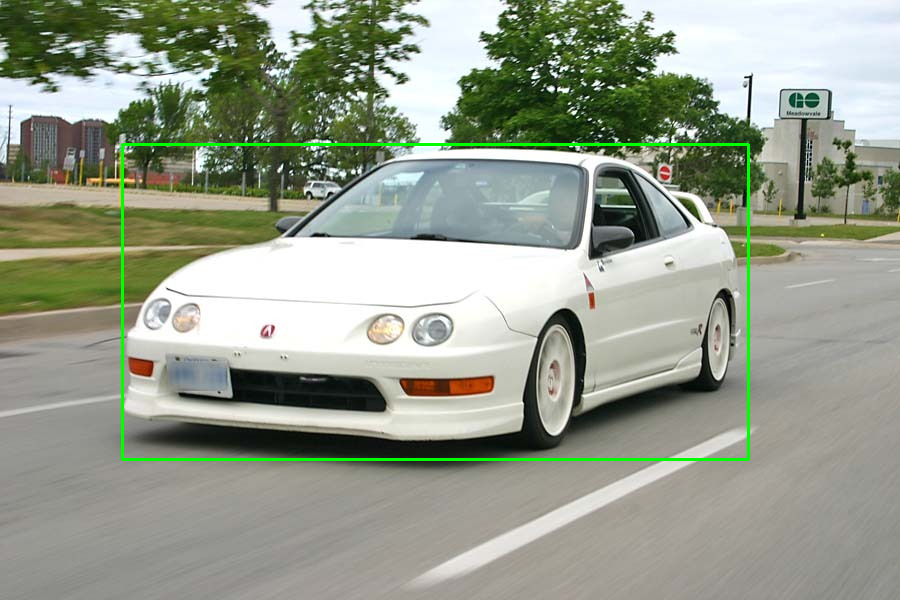

In [ ]:
# Define the bounding box coordinates
bbox_x, bbox_y = int(df[df["image_name"] == "00128.jpg"] ["bbox_x"].values), int(df[df["image_name"] == "00128.jpg"] ["bbox_y"].values)
bbox_width, bbox_height = int(df[df["image_name"] == "00128.jpg"] ["bbox_width"].values), int(df[df["image_name"] == "00128.jpg"] ["bbox_height"].values)

# Top-left and bottom-right corners
top_left = (bbox_x, bbox_y)
bottom_right = (bbox_x + bbox_width, bbox_y + bbox_height)

# Draw rectangle
thickness = 2
color = (0, 255, 0) # green
cv2.rectangle(image, top_left, bottom_right,color, thickness)

# Show image
cv2_imshow(image)

Create 3 folders corresponding to the 3 classes, each containing train, validation, and test images and labels

In [ ]:
classes = ["Acura RL Sedan 2012", "Acura Integra Type R 2001", "Acura TL Sedan 2012"]

# Create a main folder
os.makedirs("/content/car data", exist_ok=True)

# Create 3 subfolders corresponding to the 3 classes
for i in range(len(classes)):

 folders = [
    "/content/car data/"+classes[i]+"/train/images",
    "/content/car data/"+classes[i]+"/validation/images",
    "/content/car data/"+classes[i]+"/test/images",

    "/content/car data/"+classes[i]+"/train/labels",
    "/content/car data/"+classes[i]+"/validation/labels",
    "/content/car data/"+classes[i]+"/test/labels",
 ]

 for f in folders:
    Path(f).mkdir(parents=True, exist_ok=True)

Split train, validation and test images for each class to train YOLO model

In [ ]:
for i in range (len(classes)):

  # Find the CSV file that contains the image names and bounding boxes in each class folder (file generated by Make Sense, annotation software)
  path_folder_car_data_1_classe = "/content/Car_data/"+classes[i]+"/"+classes[i]+"/"
  csv_file = glob.glob(path_folder_car_data_1_classe + "/*.csv")

  # Read CSV file
  df = pd.read_csv(csv_file[0])

# Split train, validation and test images for each class using the index from the CSV file

  # Split 70% for training and 30% for testing and validation for each class
  train_idx, test_val_idx = train_test_split(df.index, test_size=0.3, random_state=42)

  # Split the remaining 30% into 10% for validation and 20% for test (approximately)
  test_idx, val_idx = train_test_split(test_val_idx, test_size=0.3, random_state=42)

  # Find the corresponding train, validation and test image names using their respective index
  train_image = np.array((df.iloc[train_idx]).image_name)
  test_image = np.array((df.iloc[test_idx]).image_name)
  val_image = np.array((df.iloc[val_idx]).image_name)


  # Copy train, validation and test images from the Car_data to the car data folder for each class
  copy_image_from_source_folder_2_dest_folder("/content/Car_data/"+classes[i]+"/"+classes[i]+"/",
                                              "/content/car data/"+classes[i]+"/train/images", train_image)

  copy_image_from_source_folder_2_dest_folder("/content/Car_data/"+classes[i]+"/"+classes[i]+"/",
                                              "/content/car data/"+classes[i]+"/validation/images", val_image)

  copy_image_from_source_folder_2_dest_folder("/content/Car_data/"+classes[i]+"/"+classes[i]+"/",
                                              "/content/car data/"+classes[i]+"/test/images", test_image)


  # Copy the train, validation and test labels (files.txt) from Car_data to the car data folder for each class
  copy_text_file_from_source_folder_2_dest_folder(search_subfolder_contain_files_txt (path_folder_car_data_1_classe),
                                              "/content/car data/"+classes[i]+"/train/labels",
                                              np.char.replace(np.array(train_image, dtype=str), '.jpg', '.txt'))

  copy_text_file_from_source_folder_2_dest_folder(search_subfolder_contain_files_txt (path_folder_car_data_1_classe),
                                              "/content/car data/"+classes[i]+"/validation/labels",
                                              np.char.replace(np.array(val_image, dtype=str), '.jpg', '.txt'))

  copy_text_file_from_source_folder_2_dest_folder(search_subfolder_contain_files_txt (path_folder_car_data_1_classe),
                                              "/content/car data/"+classes[i]+"/test/labels",
                                               np.char.replace(np.array(test_image, dtype=str), '.jpg', '.txt'))

**Configure Training**

1. Create "classes.txt" file to get list of class names

* Make Sense does NOT generate classes.txt automatically, so I need to create it manually. However, other annotation software exists that creates classes.txt automatically

In [ ]:
with open('classes.txt', 'w') as f:
    for c in classes:
        f.write(c + '\n')

2. create YAML

* A YAML (Yet Another Markup Language) file is used to define the dataset configuration. It contains information about the train and validation data paths, classes, and the number of classes

In [ ]:
# This function create the data.yaml:
#  - 1. Reads "classes.txt" file to get list of class names
#  - 2. Creates data dictionary with correct paths to folders, number of classes and names of classes
#  - 3. Writes data in YAML format to data.yaml

# path_to_classes_txt: path to the classes.txt file
# path_to_data_yaml: path where the data.yaml file will be created

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
        'train':
        ['/content/car data/Acura Integra Type R 2001/train',
        '/content/car data/Acura RL Sedan 2012/train',
        '/content/car data/Acura TL Sedan 2012/train'],

        'val':
        ['/content/car data/Acura Integra Type R 2001/validation',
        '/content/car data/Acura RL Sedan 2012/validation',
        '/content/car data/Acura TL Sedan 2012/validation' ],

       'nc': number_of_classes,
       'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/classes.txt'
path_to_data_yaml =   '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

train:
- /content/car data/Acura Integra Type R 2001/train
- /content/car data/Acura RL Sedan 2012/train
- /content/car data/Acura TL Sedan 2012/train
val:
- /content/car data/Acura Integra Type R 2001/validation
- /content/car data/Acura RL Sedan 2012/validation
- /content/car data/Acura TL Sedan 2012/validation
nc: 3
names:
- Acura RL Sedan 2012
- Acura Integra Type R 2001
- Acura TL Sedan 2012


3. Install Requirements (Ultralytics)

- Python library will be used to train the YOLO model.



In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.2 MB/s eta 0:00:00


4. Train model

In [45]:
 # - What happens when you run it:
 #  1. Loads pretrained weights (yolo11n.pt)
 #  2. Reads dataset from data.yaml
 #  3. Trains model for n epochs
 #  4. Saves results in: /content/runs/detect/train (by default)

!yolo detect train data=/content/data.yaml model=yolo11n.pt epochs=80 imgsz=640

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

**Test the model using the test data**

In [71]:
from ultralytics import YOLO

# A class that predicts images by running a trained YOLO model and displays the predicted images
class Test_model_and_disp_img:

 # Class attribute shared by all instances (static variable)
    results = None

# Function to predict images by running a YOLO trained model and save them
# source: path to the folder containing test images
# project: path to the folder that contains predicted images
# model: path to the trained model to load
    def Test_model (self, model_path, source, project):
        model = YOLO(model_path)
        self.results = model.predict(
            source=source,
            project=project,
            conf=0.8,        # Confidence threshold (only show > 80%) : The conf ensures only predictions with > 80% confidence are shown/saved.
            save=True
        )

# Function to display the predicted images
# nb_image_to_visualise: number of predicted images to display
    def display_pred_images (self, nb_image_to_visualise):
       image_paths = glob.glob(os.path.join(self.results[0].save_dir, "*.jpg"))
       for i, image_path in enumerate(image_paths[:nb_image_to_visualise]):
         print("Image number", i+1)
         display(Image(filename=image_path, height=400))
         print("\n")

1. 1st class: Acura Integra Type R 2001

In [72]:
# Create an instance of Test_model_and_disp_img
test_model_and_disp_img = Test_model_and_disp_img()


image 1/18 /content/car data/Acura Integra Type R 2001/test/images/00198.jpg: 480x640 1 Acura Integra Type R 2001, 11.8ms
image 2/18 /content/car data/Acura Integra Type R 2001/test/images/00711.jpg: 352x640 1 Acura Integra Type R 2001, 9.8ms
image 3/18 /content/car data/Acura Integra Type R 2001/test/images/00878.jpg: 480x640 1 Acura Integra Type R 2001, 10.1ms
image 4/18 /content/car data/Acura Integra Type R 2001/test/images/01911.jpg: 480x640 1 Acura Integra Type R 2001, 8.8ms
image 5/18 /content/car data/Acura Integra Type R 2001/test/images/02011.jpg: 448x640 1 Acura Integra Type R 2001, 9.3ms
image 6/18 /content/car data/Acura Integra Type R 2001/test/images/02095.jpg: 448x640 1 Acura Integra Type R 2001, 8.9ms
image 7/18 /content/car data/Acura Integra Type R 2001/test/images/02798.jpg: 448x640 1 Acura Integra Type R 2001, 13.4ms
image 8/18 /content/car data/Acura Integra Type R 2001/test/images/03748.jpg: 448x640 1 Acura Integra Type R 2001, 8.6ms
image 9/18 /content/car data

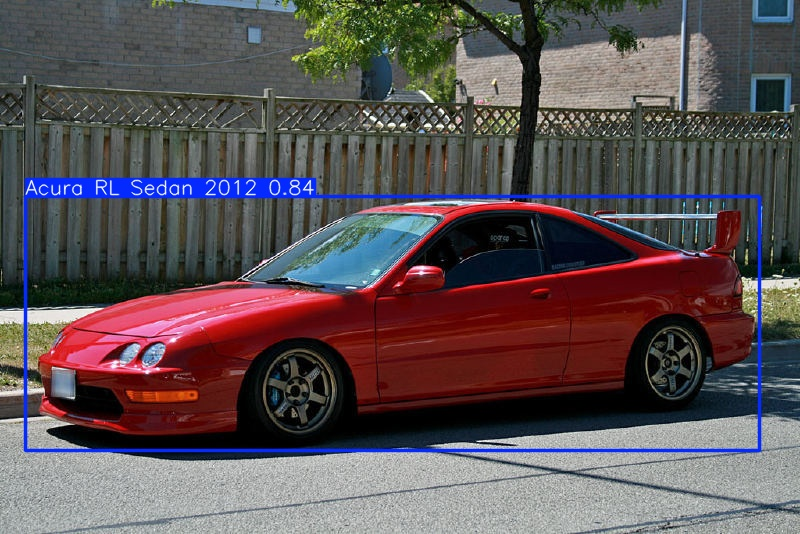



Image number 2


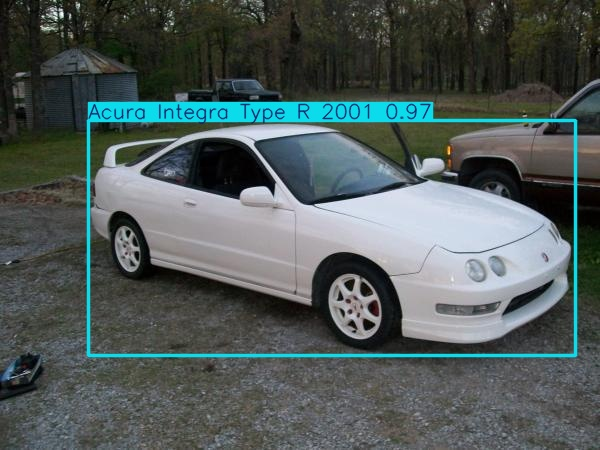



Image number 3


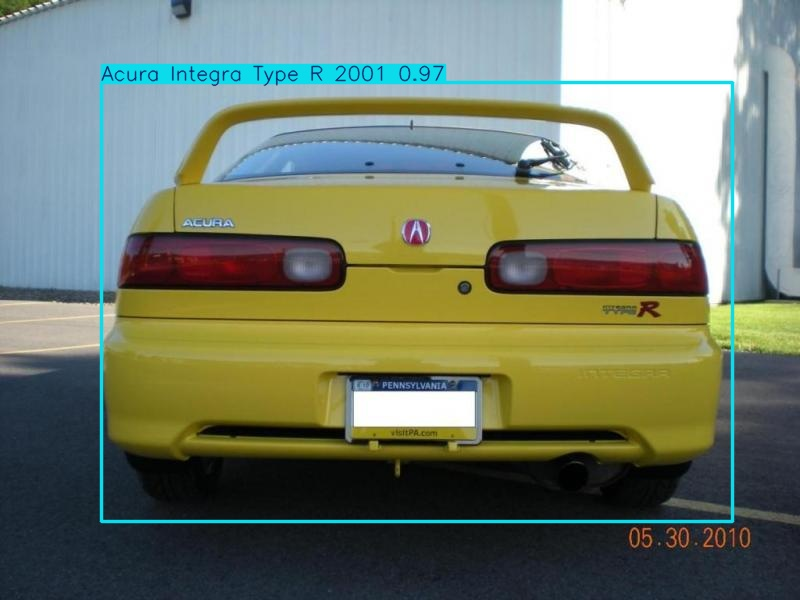



Image number 4


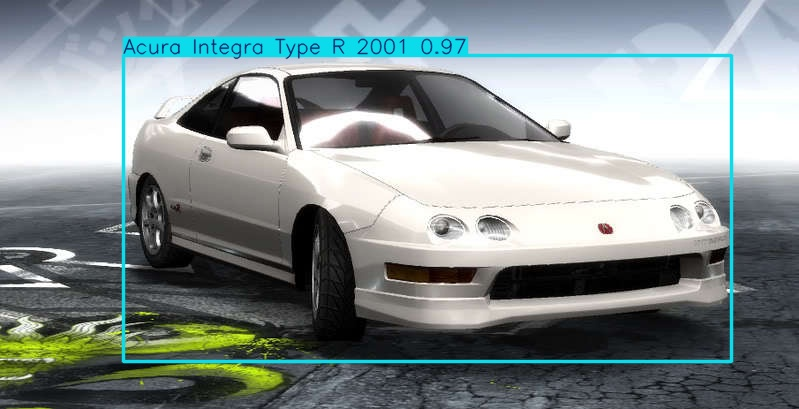



Image number 5


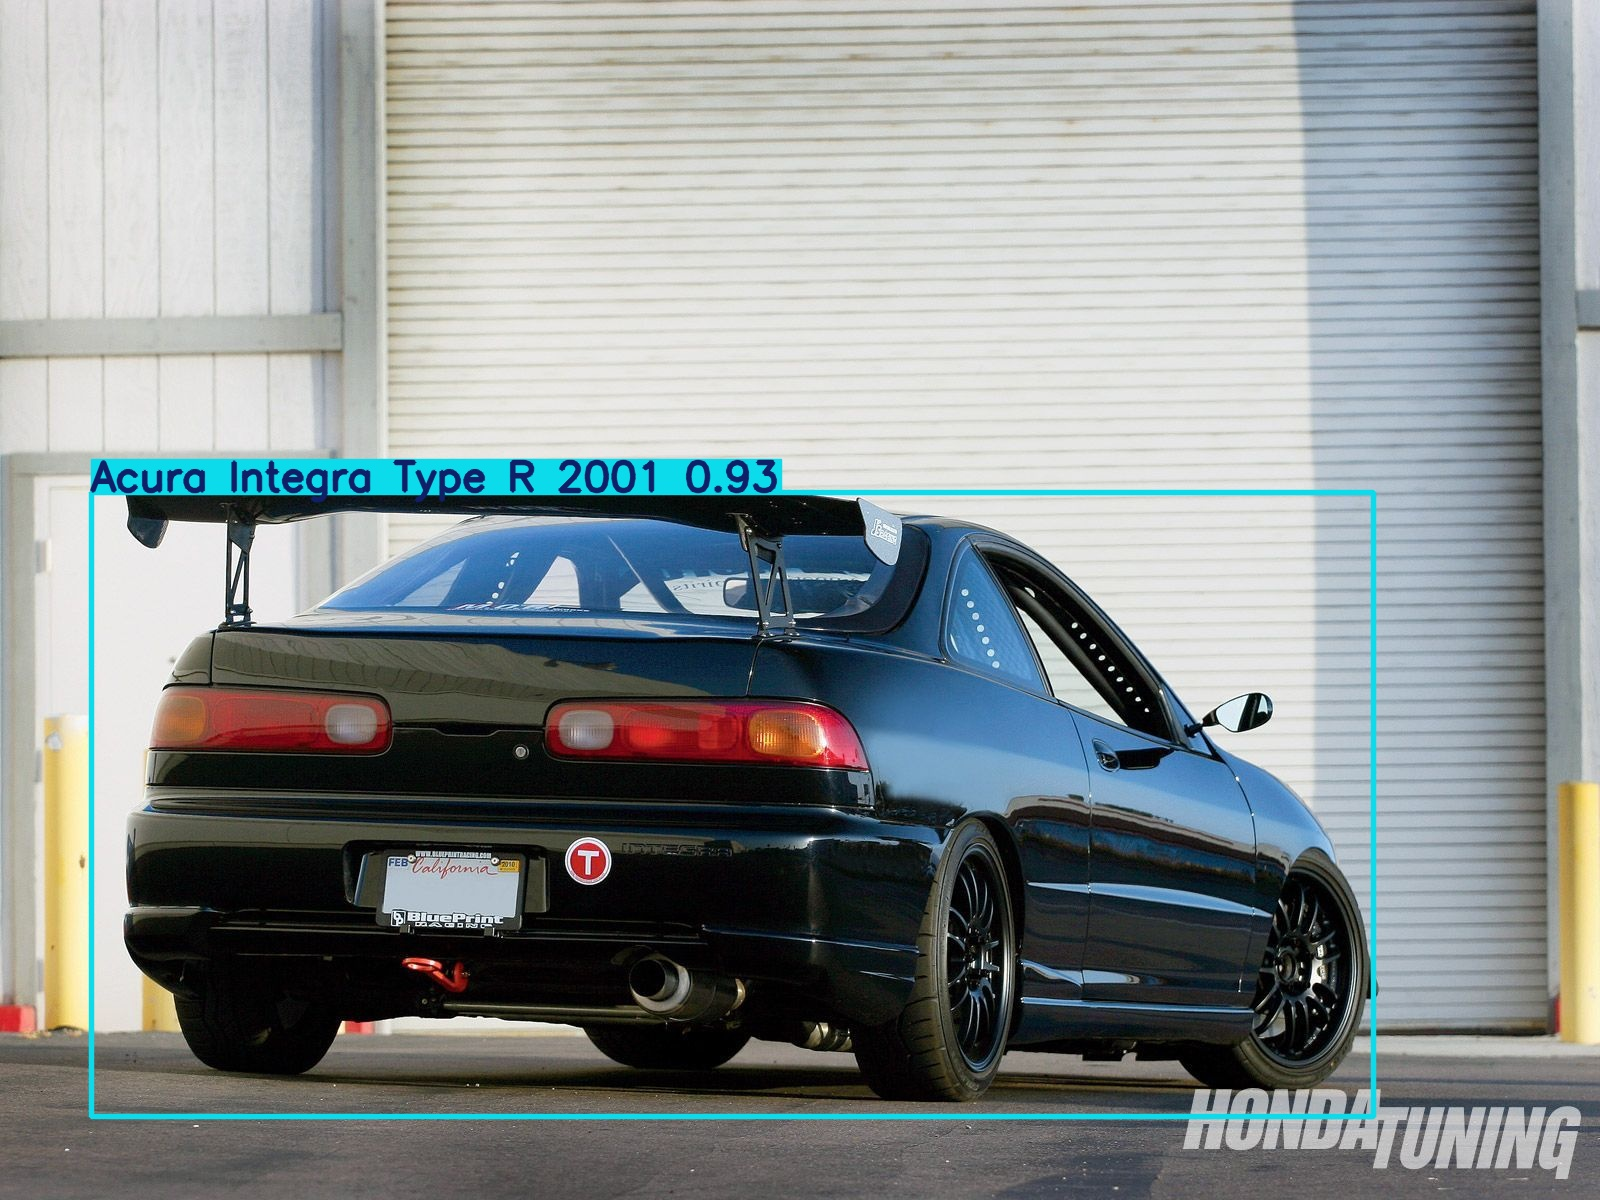



Image number 6


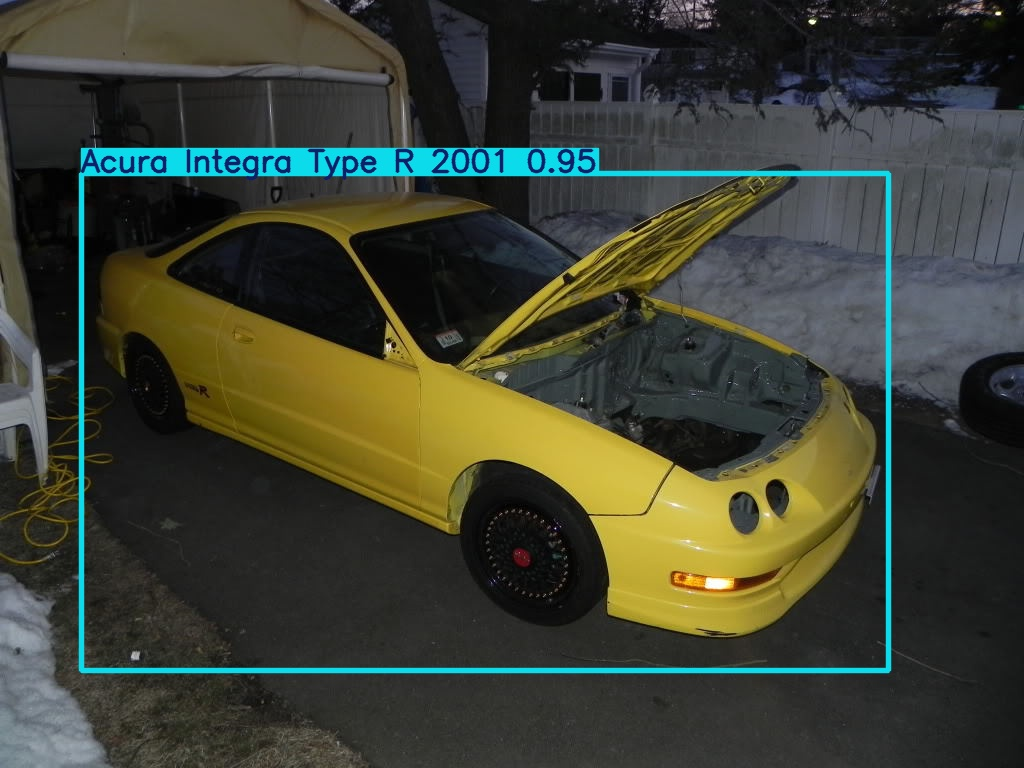



Image number 7


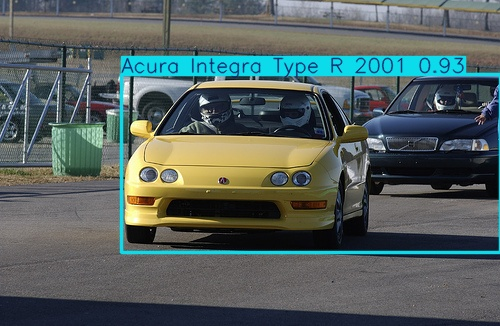



Image number 8


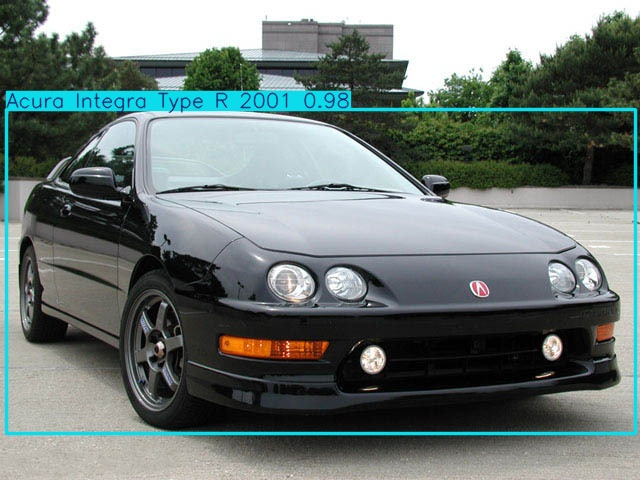



Image number 9


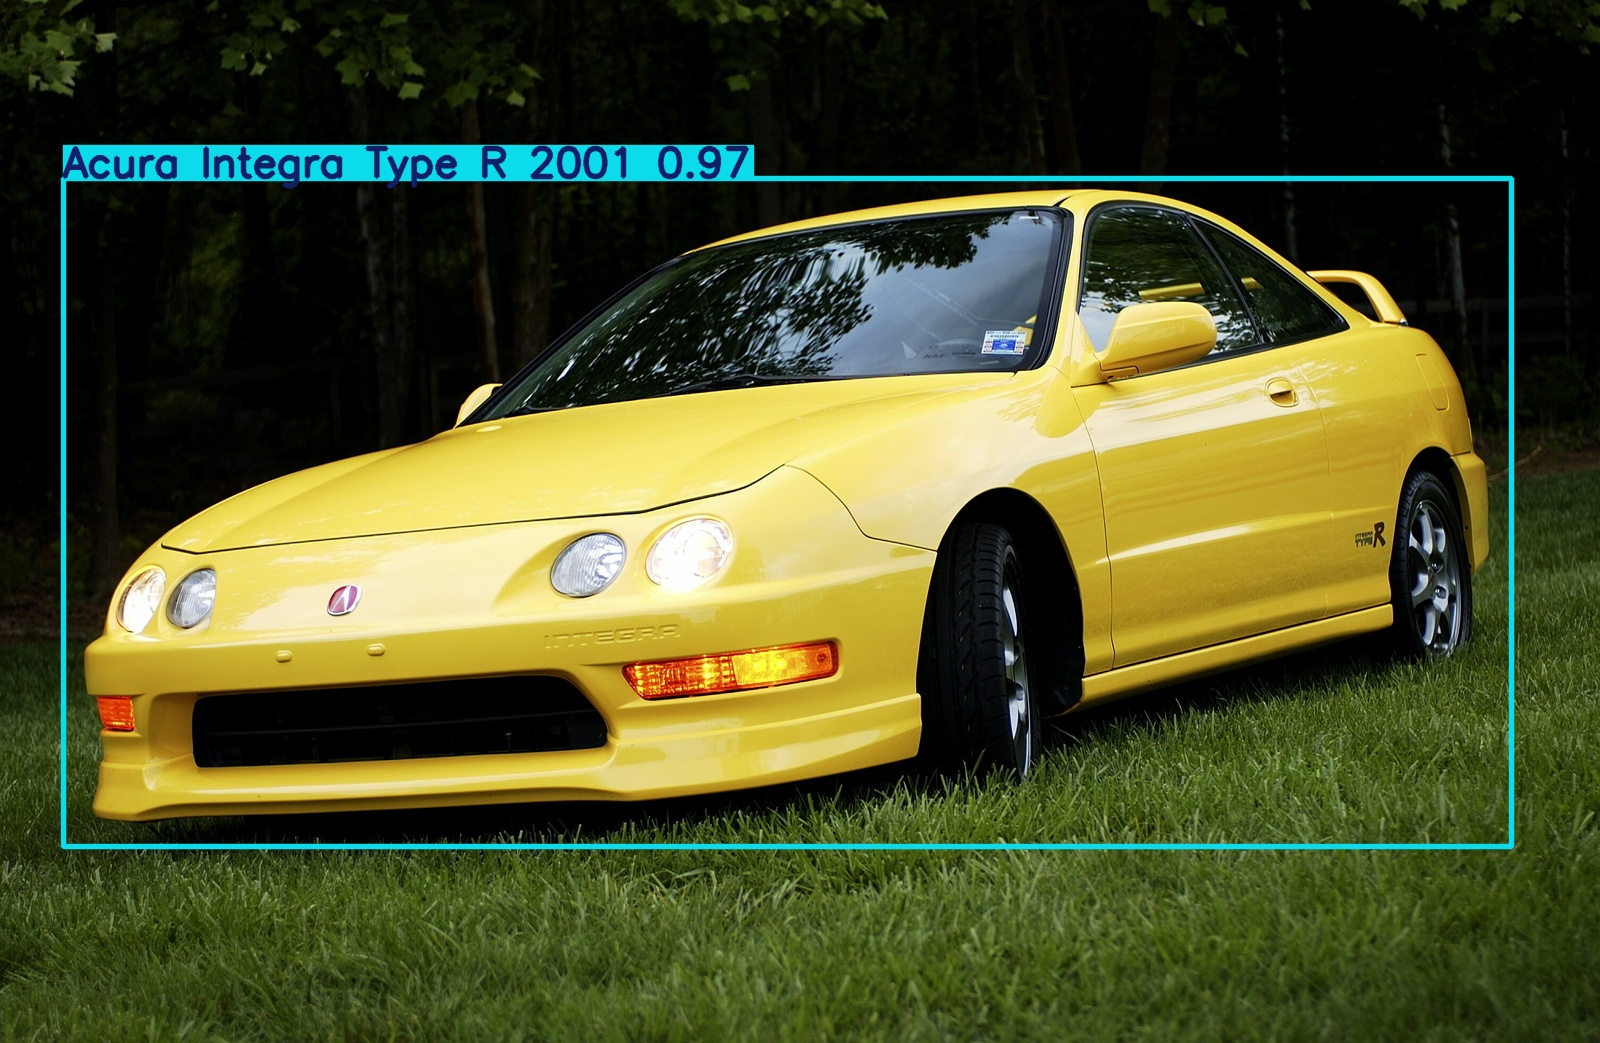



Image number 10


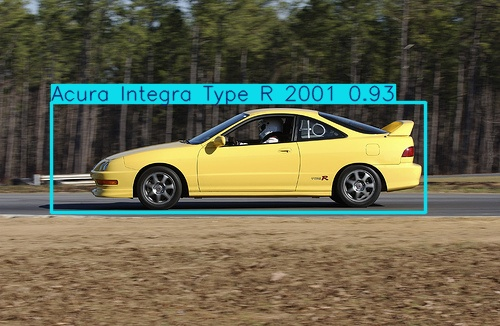



Image number 11


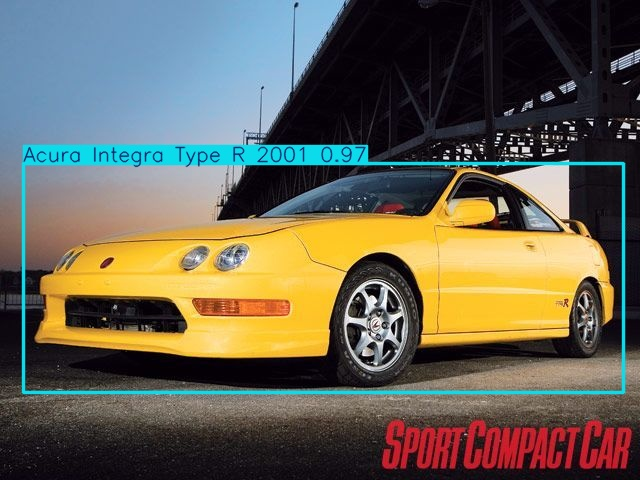



Image number 12


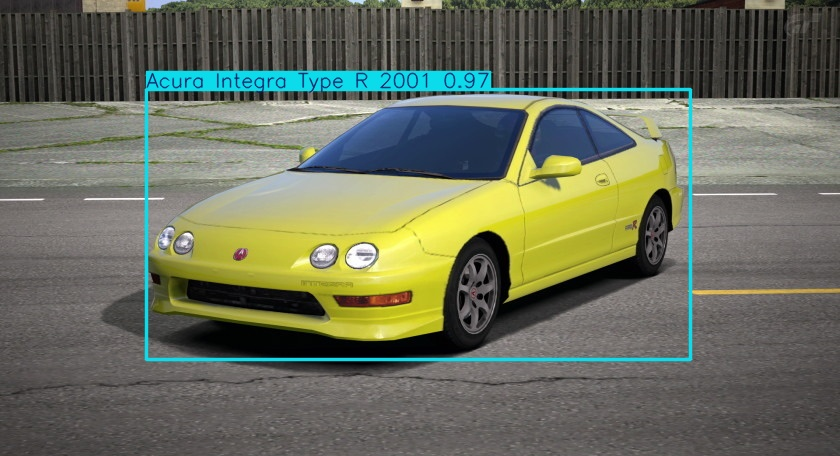



Image number 13


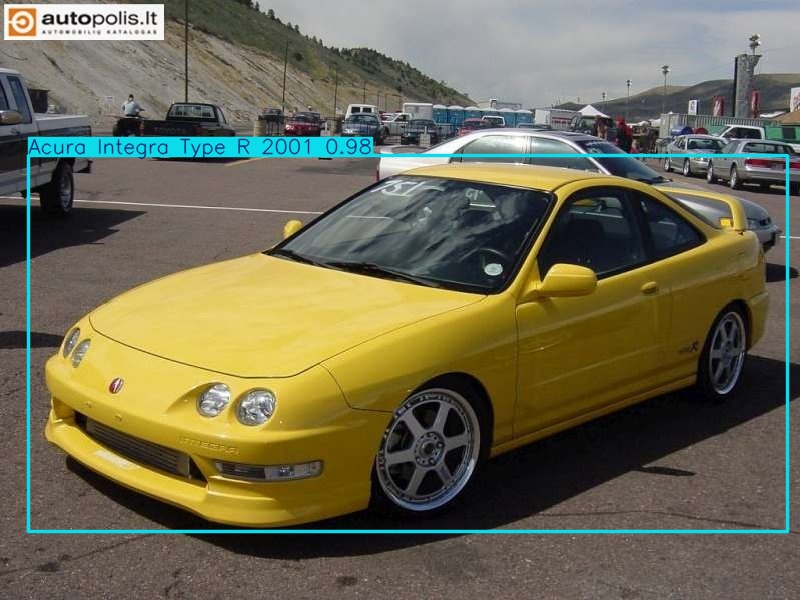



Image number 14


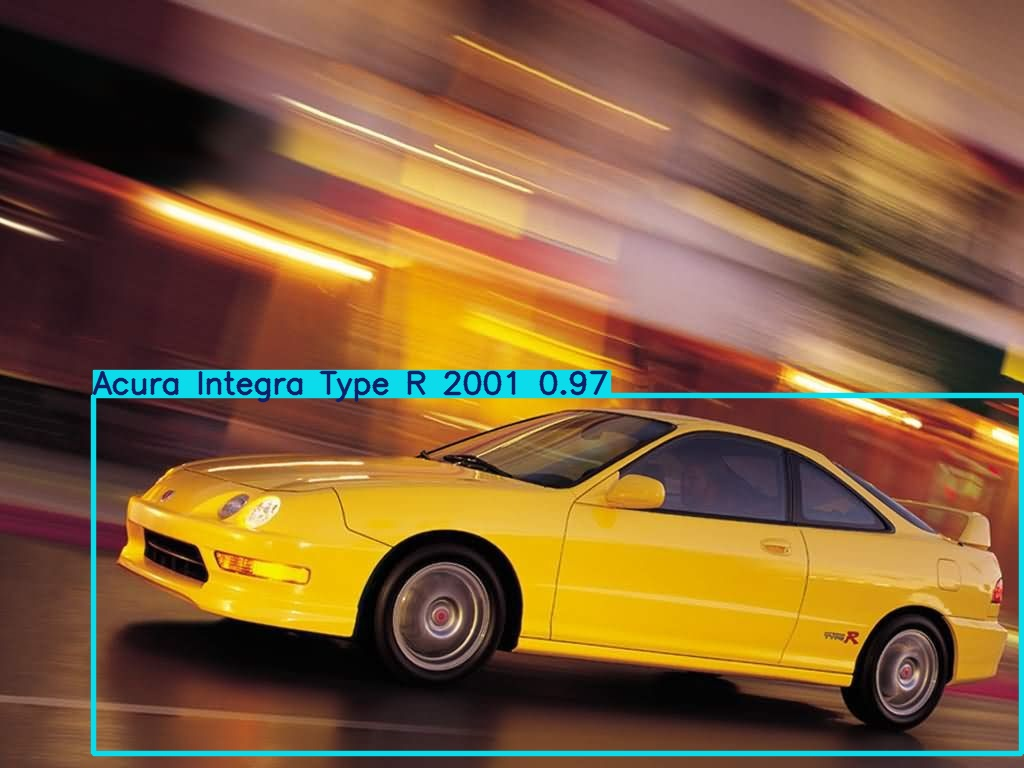



Image number 15


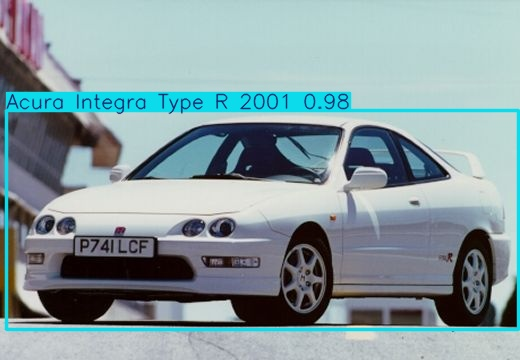



Image number 16


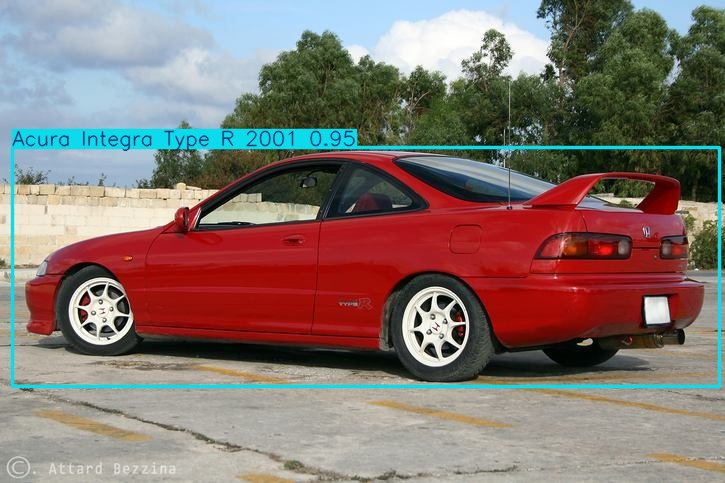



Image number 17


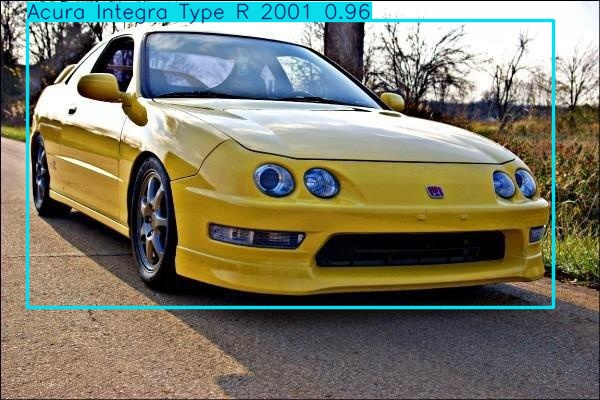



Image number 18


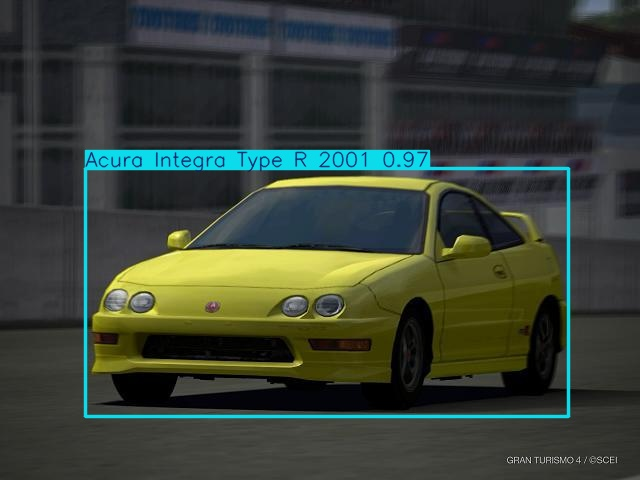

In [73]:
# Loads YOLO model, predicts 1st class test images, and displays results
test_model_and_disp_img.Test_model("/content/runs/detect/train/weights/best.pt",
                                  "/content/car data/Acura Integra Type R 2001/test/images",
                                  "/content/predictions_Acura Integra Type R 2001")

test_model_and_disp_img.display_pred_images (18)

2. 2nd class: Acura RL Sedan 2012


image 1/14 /content/car data/Acura RL Sedan 2012/test/images/00347.jpg: 256x640 1 Acura RL Sedan 2012, 20.4ms
image 2/14 /content/car data/Acura RL Sedan 2012/test/images/00670.jpg: 448x640 1 Acura RL Sedan 2012, 13.3ms
image 3/14 /content/car data/Acura RL Sedan 2012/test/images/01031.jpg: 256x640 1 Acura RL Sedan 2012, 13.2ms
image 4/14 /content/car data/Acura RL Sedan 2012/test/images/01535.jpg: 320x640 1 Acura RL Sedan 2012, 13.1ms
image 5/14 /content/car data/Acura RL Sedan 2012/test/images/01698.jpg: 416x640 1 Acura RL Sedan 2012, 11.3ms
image 6/14 /content/car data/Acura RL Sedan 2012/test/images/02314.jpg: 448x640 1 Acura RL Sedan 2012, 12.8ms
image 7/14 /content/car data/Acura RL Sedan 2012/test/images/02540.jpg: 480x640 (no detections), 12.7ms
image 8/14 /content/car data/Acura RL Sedan 2012/test/images/03267.jpg: 448x640 1 Acura RL Sedan 2012, 16.7ms
image 9/14 /content/car data/Acura RL Sedan 2012/test/images/03306.jpg: 416x640 1 Acura RL Sedan 2012, 12.4ms
image 10/14 /co

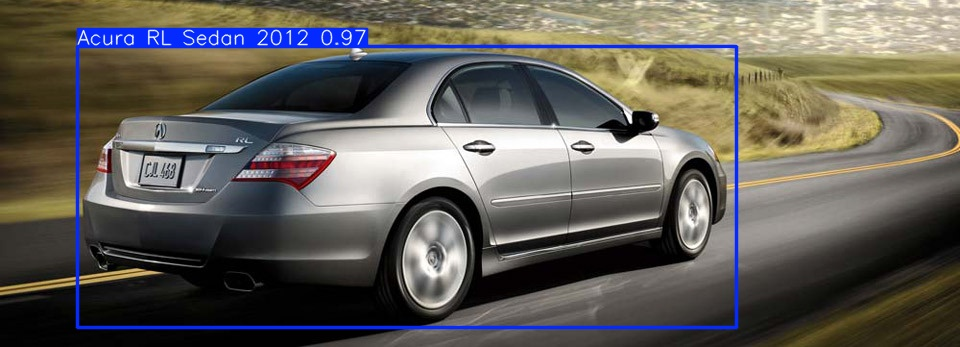



Image number 2


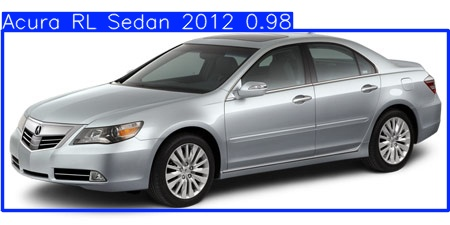



Image number 3


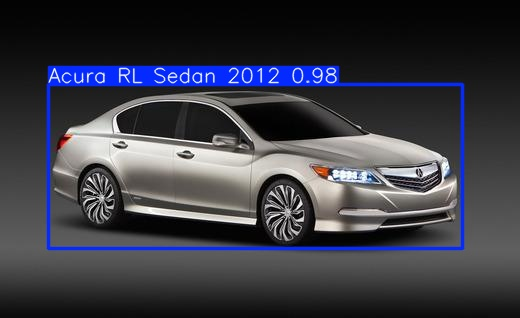



Image number 4


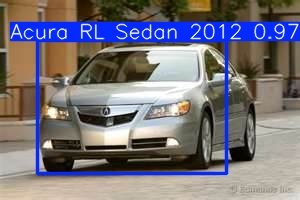



Image number 5


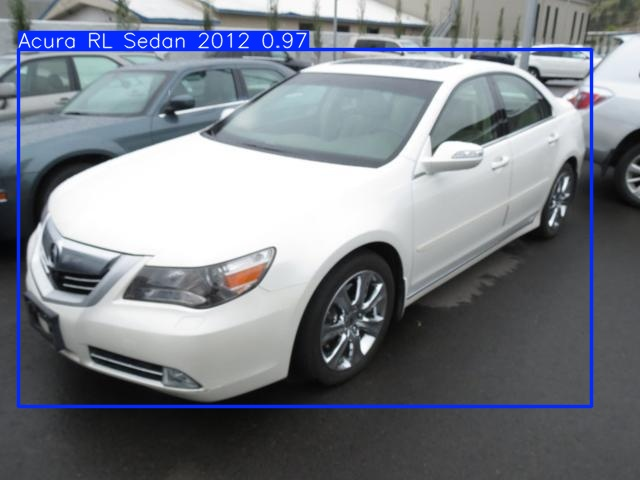



Image number 6


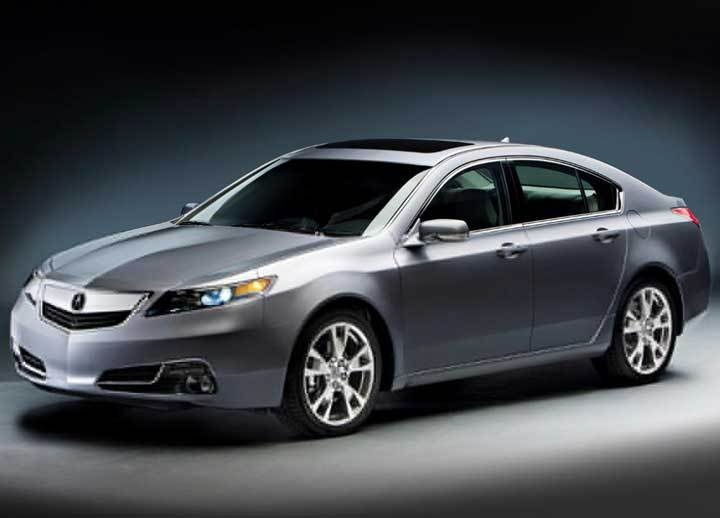



Image number 7


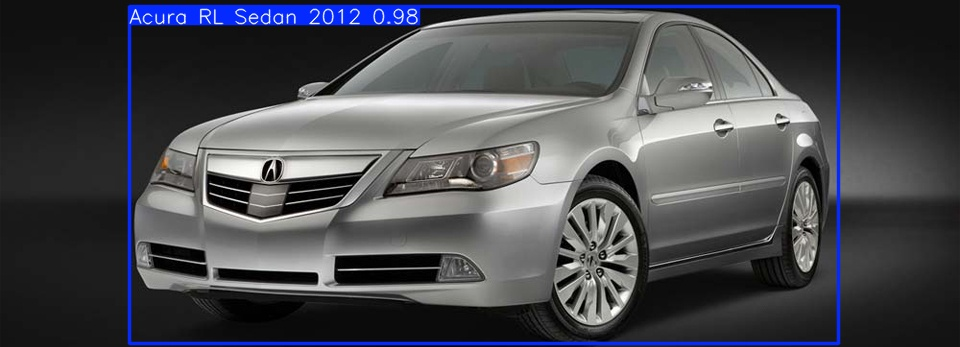



Image number 8


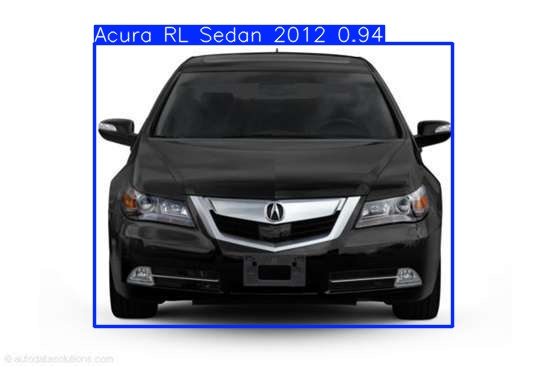



Image number 9


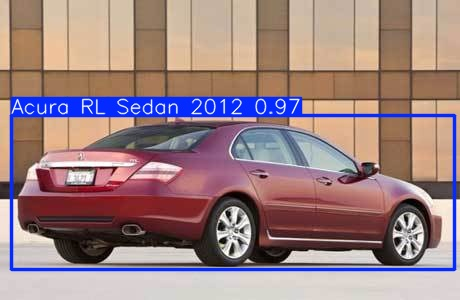



Image number 10


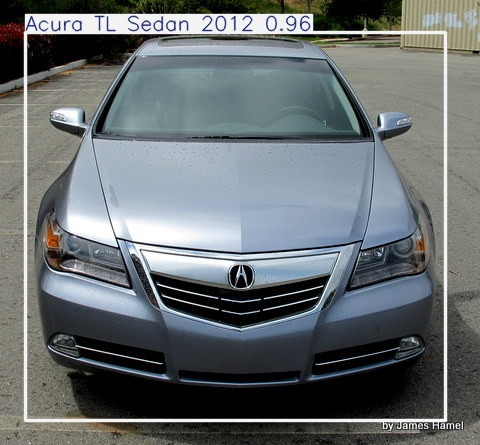



Image number 11


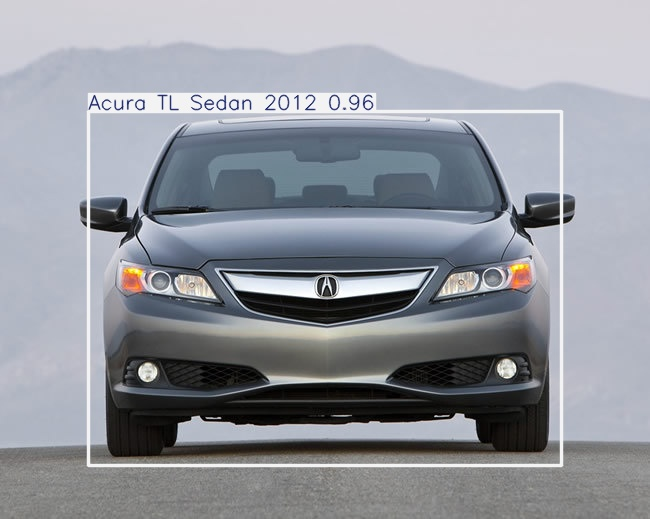



Image number 12


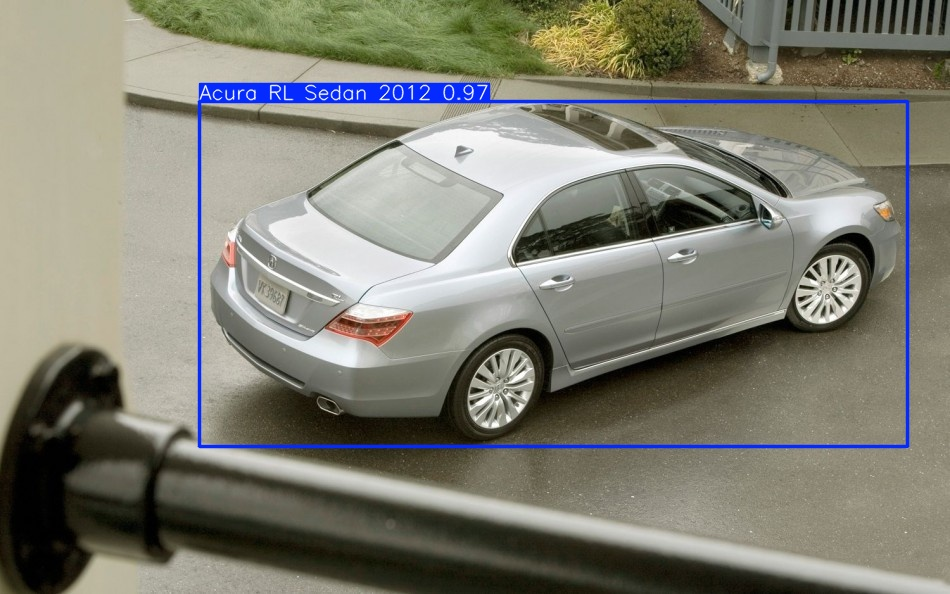



Image number 13


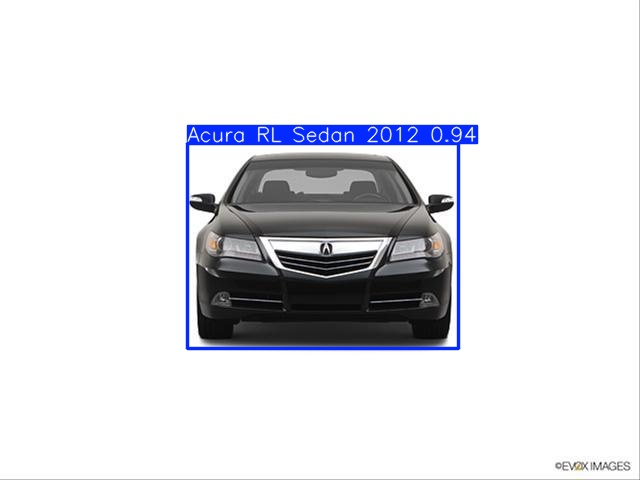



Image number 14


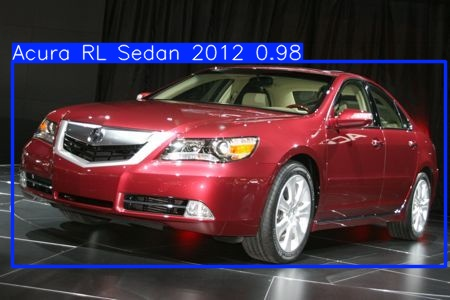

In [75]:
# Loads YOLO model, predicts 2nd class test images, and displays results
test_model_and_disp_img.Test_model("/content/runs/detect/train/weights/best.pt",
                                   "/content/car data/Acura RL Sedan 2012/test/images",
                                    "/content/predictions_Acura RL Sedan 2012")

test_model_and_disp_img.display_pred_images(14)

3. 3rd class: Acura TL Sedan 2012


image 1/18 /content/car data/Acura TL Sedan 2012/test/images/01162.jpg: 480x640 1 Acura TL Sedan 2012, 9.8ms
image 2/18 /content/car data/Acura TL Sedan 2012/test/images/01214.jpg: 480x640 1 Acura TL Sedan 2012, 9.6ms
image 3/18 /content/car data/Acura TL Sedan 2012/test/images/01406.jpg: 384x640 1 Acura TL Sedan 2012, 9.9ms
image 4/18 /content/car data/Acura TL Sedan 2012/test/images/01911.jpg: 480x640 1 Acura TL Sedan 2012, 10.0ms
image 5/18 /content/car data/Acura TL Sedan 2012/test/images/02589.jpg: 480x640 1 Acura TL Sedan 2012, 13.0ms
image 6/18 /content/car data/Acura TL Sedan 2012/test/images/03174.jpg: 480x640 1 Acura TL Sedan 2012, 9.1ms
image 7/18 /content/car data/Acura TL Sedan 2012/test/images/03365.jpg: 288x640 1 Acura RL Sedan 2012, 11.5ms
image 8/18 /content/car data/Acura TL Sedan 2012/test/images/04757.jpg: 480x640 1 Acura TL Sedan 2012, 9.7ms
image 9/18 /content/car data/Acura TL Sedan 2012/test/images/05545.jpg: 384x640 1 Acura TL Sedan 2012, 10.2ms
image 10/18 /c

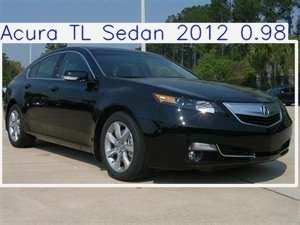



Image number 2


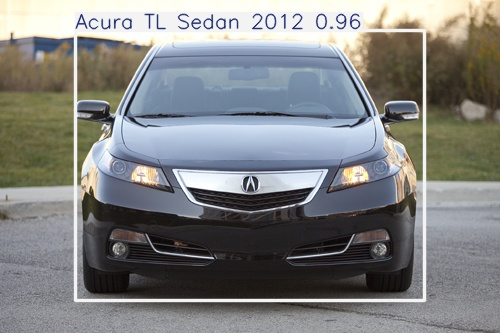



Image number 3


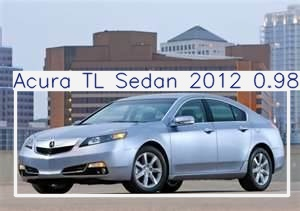



Image number 4


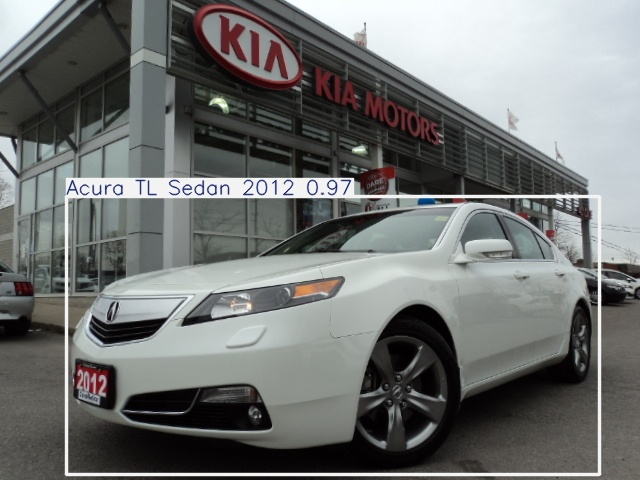



Image number 5


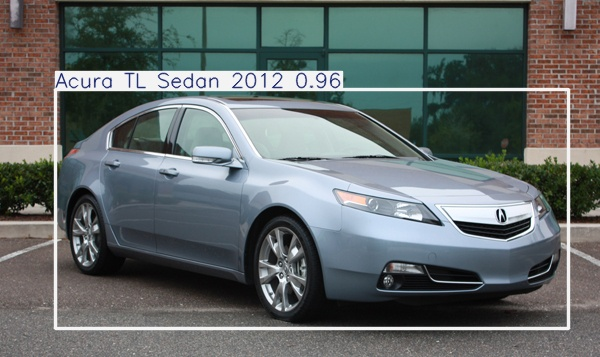



Image number 6


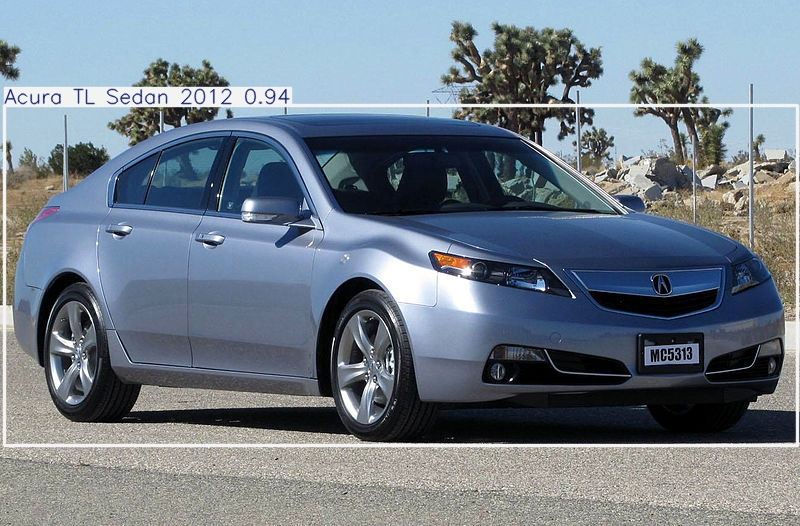



Image number 7


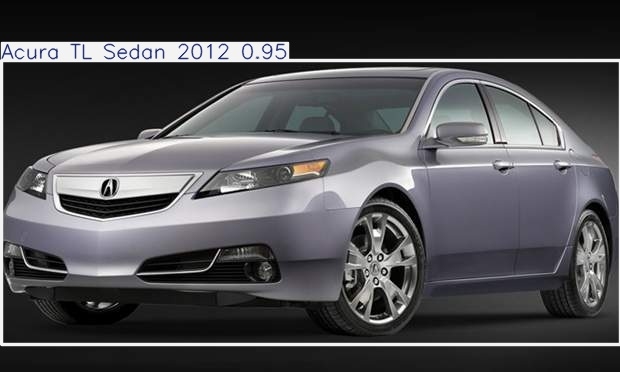



Image number 8


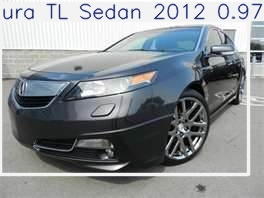



Image number 9


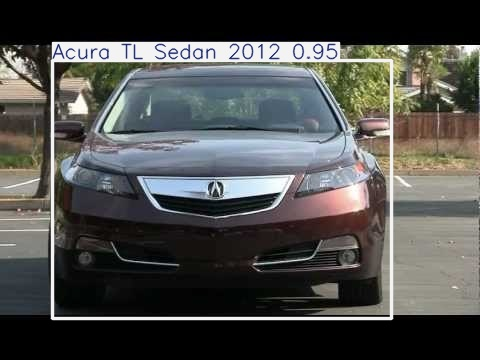



Image number 10


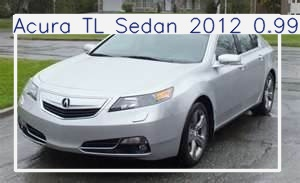



Image number 11


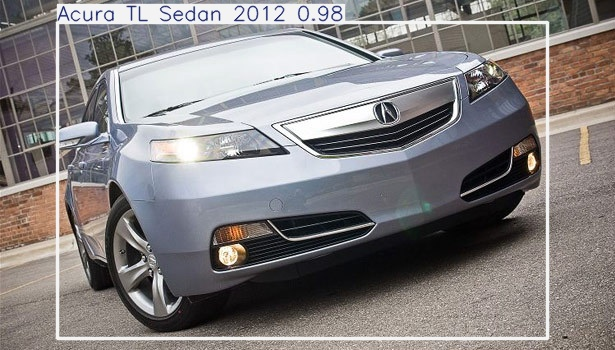



Image number 12


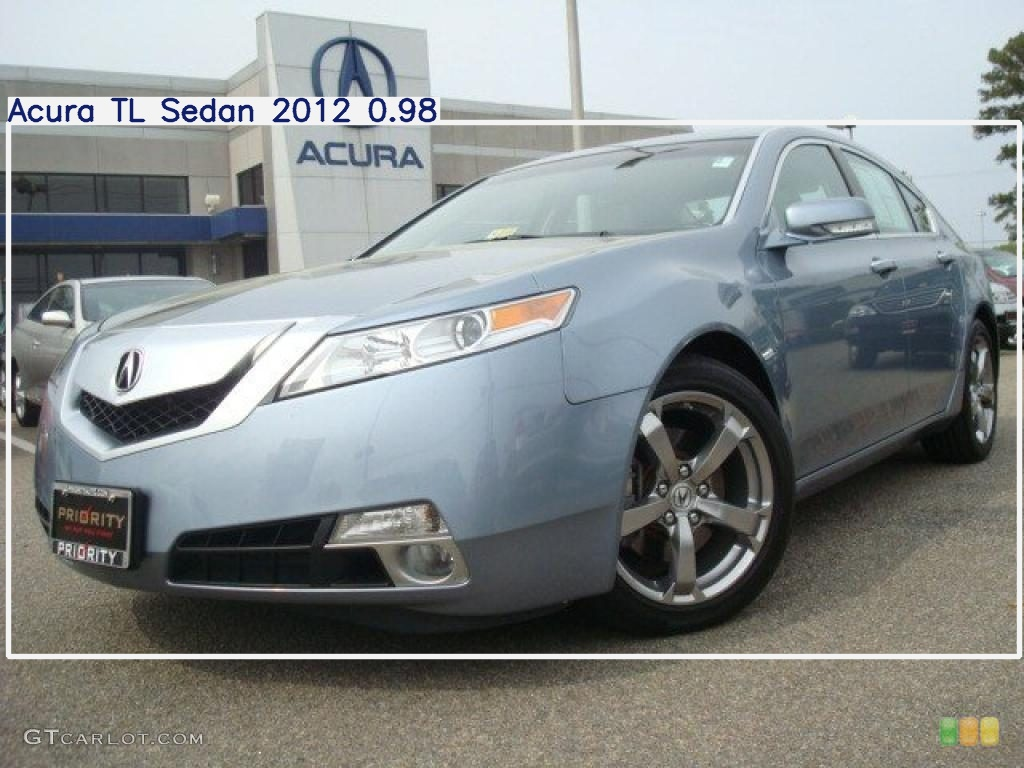



Image number 13


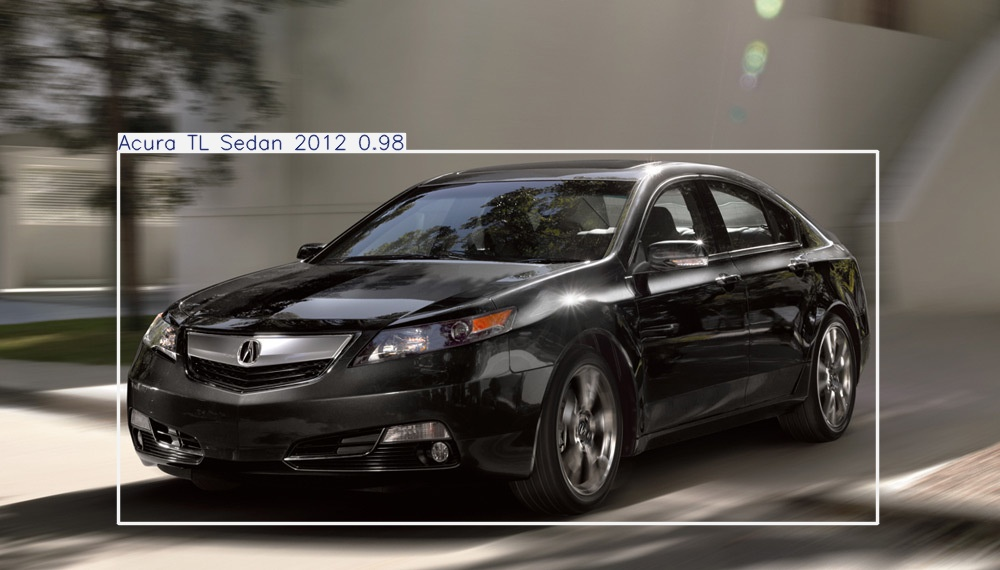



Image number 14


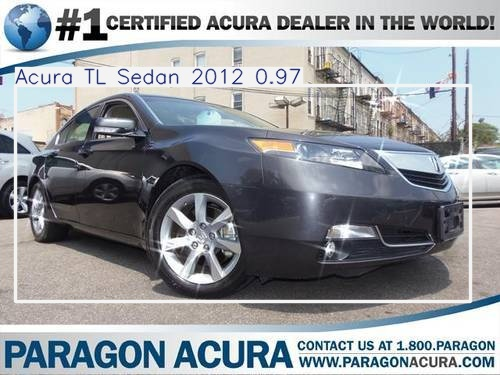



Image number 15


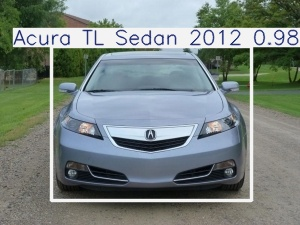



Image number 16


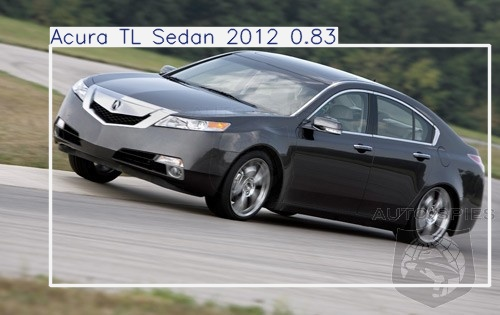



Image number 17


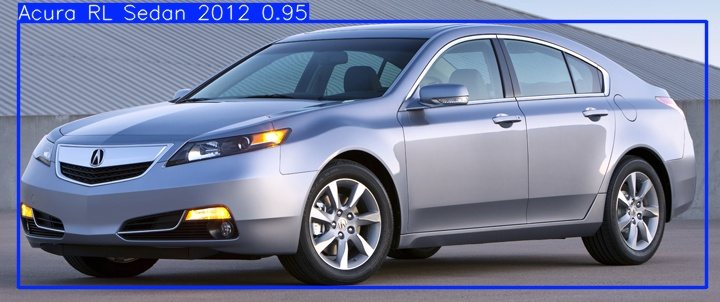



Image number 18


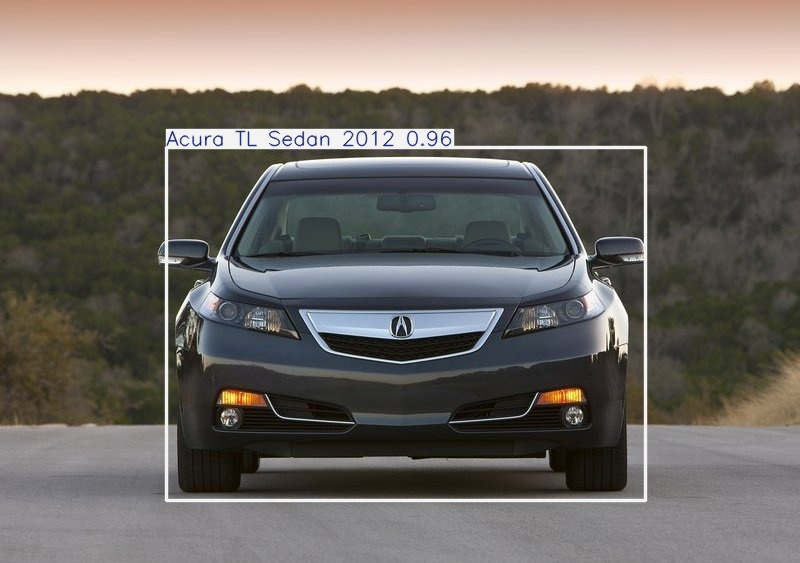

In [74]:
# Loads YOLO model, predicts 3rd class test images, and displays results
test_model_and_disp_img.Test_model("/content/runs/detect/train/weights/best.pt",
                                  "/content/car data/Acura TL Sedan 2012/test/images",
                                   "/content/predictions_Acura TL Sedan 2012")

test_model_and_disp_img.display_pred_images(18)